# Minimum Atomworks Output Analysis

This notebook reads `pdb.parquet` and `dataset.parquet` directly from a run output directory, summarizes the contents, and makes a few quick matplotlib plots for structure-, interface-, and dataset-level inspection.

Edit `OUT_DIR` in the next cell if you want to force a specific run directory.

In [52]:
from __future__ import annotations

import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

REPO_ROOT = Path('/home/eva/minimum_atomworks')
OUT_DIR = None


def detect_out_dir(root: Path) -> Path:
    candidates = []
    for path in root.glob('out*'):
        if path.is_dir() and (path / 'pdb.parquet').exists():
            candidates.append(path)
    if not candidates:
        raise FileNotFoundError(f'No output directory with pdb.parquet found under {root}')
    return max(candidates, key=lambda item: item.stat().st_mtime)


out_dir = Path(OUT_DIR).expanduser().resolve() if OUT_DIR else detect_out_dir(REPO_ROOT)
pdb_path = out_dir / 'pdb.parquet'
dataset_path = out_dir / 'dataset.parquet'
run_metadata_path = out_dir / 'run_metadata.json'
dataset_metadata_path = out_dir / 'dataset_metadata.json'

print(f'Using out_dir: {out_dir}')
print(f'pdb.parquet exists: {pdb_path.exists()}')
print(f'dataset.parquet exists: {dataset_path.exists()}')
print(f'run_metadata.json exists: {run_metadata_path.exists()}')
print(f'dataset_metadata.json exists: {dataset_metadata_path.exists()}')

Using out_dir: /home/eva/minimum_atomworks/out_antibody_antigen_pdb
pdb.parquet exists: True
dataset.parquet exists: True
run_metadata.json exists: True
dataset_metadata.json exists: False


In [53]:
dataset_df = pd.read_parquet(dataset_path)
print(f'dataset_df shape: {dataset_df.shape}')
display(dataset_df.head(30))

dataset_df shape: (10, 10)


,analysis,key,value,source,pair,n_rows,n_unique_paths,mean_contact_atom_pairs,mean_left_interface_residues,mean_right_interface_residues
0,dataset_annotations,n_interface_rows,10,derived,None,NaN,NaN,NaN,NaN,NaN
1,dataset_annotations,n_unique_structures,10,derived,None,NaN,NaN,NaN,NaN,NaN
2,dataset_annotations,n_role_rows,40,derived,None,NaN,NaN,NaN,NaN,NaN
3,dataset_annotations,dataset_name,antibody_antigen_full_local,config,None,NaN,NaN,NaN,NaN,NaN
4,dataset_annotations,modality,antibody_antigen,config,None,NaN,NaN,NaN,NaN,NaN
5,dataset_annotations,profile,all_non_rosetta_features_enabled,config,None,NaN,NaN,NaN,NaN,NaN
6,dataset_annotations,project,atomworks_example,config,None,NaN,NaN,NaN,NaN,NaN
7,dataset_annotations,reference_model,rank_001_alphafold2_multimer_v3_model_3_seed_0...,config,None,NaN,NaN,NaN,NaN,NaN
8,dataset_annotations,source,atw_pp default input,config,None,NaN,NaN,NaN,NaN,NaN
9,interface_summary,None,None,None,antibody__antigen,10.0,10.0,625.2,28.8,29.1


In [54]:
# read pdb.parquet
pdb_df = pd.read_parquet(pdb_path)
print(f'pdb_df shape: {pdb_df.shape}')
display(pdb_df.head(20))

pdb_df shape: (90, 101)


,path,assembly_id,grain,chain_id,role,pair,role_left,role_right,continuity__has_break,continuity__n_breaks,clash__has_clash,clash__n_clashing_atom_pairs,clash__n_clashing_atoms,center__centroid_x,center__centroid_y,center__centroid_z,sup__reference_path,sup__on_chains,sup__anchor_atoms_fixed,sup__anchor_atoms_mobile,sup__alignment_method,sup__complex_rmsd,sup__complex_matched_atoms,sup__rmsd,sup__matched_atoms,id__n_atoms_total,id__n_chains,id__has_nan_coord,id__n_atoms,chstat__n_residues,chstat__centroid_x,chstat__centroid_y,chstat__centroid_z,chstat__radius_of_gyration,rolseq__chain_ids,rolseq__n_chains,rolseq__sequence_length_total,rolseq__sequence,rolseq__sequence_by_chain,rolstat__n_residues,rolstat__centroid_x,rolstat__centroid_y,rolstat__centroid_z,rolstat__radius_of_gyration,abepitope__atom_radius,abepitope__score,abepitope__target_score,iface__contact_distance,iface__n_contact_atom_pairs,iface__n_left_contact_atoms,iface__n_right_contact_atoms,iface__n_left_interface_residues,iface__n_right_interface_residues,iface__left_interface_residues,iface__right_interface_residues,iface__n_left_vh_cdr1_interface_residues,iface__left_vh_cdr1_interface_residues,iface__n_left_vh_cdr2_interface_residues,iface__left_vh_cdr2_interface_residues,iface__n_left_vh_cdr3_interface_residues,iface__left_vh_cdr3_interface_residues,iface__n_left_vl_cdr1_interface_residues,iface__left_vl_cdr1_interface_residues,iface__n_left_vl_cdr2_interface_residues,iface__left_vl_cdr2_interface_residues,iface__n_left_vl_cdr3_interface_residues,iface__left_vl_cdr3_interface_residues,ifm__contact_distance,ifm__cell_size,ifm__n_residue_contact_pairs,ifm__residue_contact_pairs,ifm__left_interface_residue_labels,ifm__right_interface_residue_labels,ifm__left_n_interface_residues,ifm__left_interface_charge_sum,ifm__left_interface_hydrophobic_fraction,ifm__left_interface_polar_fraction,ifm__left_interface_aromatic_fraction,ifm__left_interface_glycine_fraction,ifm__left_interface_proline_fraction,ifm__right_n_interface_residues,ifm__right_interface_charge_sum,ifm__right_interface_hydrophobic_fraction,ifm__right_interface_polar_fraction,ifm__right_interface_aromatic_fraction,ifm__right_interface_glycine_fraction,ifm__right_interface_proline_fraction,abcdr__chain_ids,abcdr__numbering_scheme,abcdr__cdr_definition,abcdr__sequence_length,abcdr__cdr1_length,abcdr__cdr2_length,abcdr__cdr3_length,abseq__chain_ids,abseq__numbering_scheme,abseq__cdr_definition,abseq__sequence_length,abseq__cdr1_sequence,abseq__cdr2_sequence,abseq__cdr3_sequence
0,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,A,,,,,True,1.0,None,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,None,NaN,NaN,0.000009,906.0,NaN,NaN,None,906.0,115.0,5.403358,-27.414461,-16.556015,27.464626,None,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,None,NaN,None,NaN,None,NaN,None,NaN,None,NaN,None,NaN,NaN,NaN,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,NaN,NaN,NaN,NaN,None,None,None,NaN,None,None,None
1,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,B,,,,,False,0.0,None,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,None,NaN,NaN,0.000006,1634.0,NaN,NaN,None,1634.0,212.0,6.816290,6.250148,8.639813,39.049828,None,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,None,NaN,None,NaN,None,NaN,None,NaN,None,NaN,None,NaN,NaN,NaN,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,NaN,NaN,NaN,NaN,None,None,None,NaN,None,None,None
2,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,C,,,,,True,1.0,None,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,None,NaN,NaN,0.000006,1563.0,NaN,NaN,None,1563.0,209.0,-7.932692,8.481285,-1.935886,40.783100,None,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,None,NaN,None,NaN,None,NaN,None,NaN,None,NaN,None,NaN,NaN,NaN,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,Na

In [55]:
# seperating this one dataset based on the grain column 
# only keep the column is they are not all Nan
grains = pdb_df['grain'].unique()
grain_dfs = {}
for grain in grains:
    grain_df = pdb_df[pdb_df['grain'] == grain]
    # drop columns that are all NaN
    grain_df = grain_df.dropna(axis=1, how='all')
    # drop columns that is empty string
    grain_df = grain_df.replace('', np.nan).dropna(axis=1, how='all')
    grain_dfs[grain] = grain_df
    print(f'Grain: {grain}, shape: {grain_df.shape}')
    display(grain_df.head(20))
    
    

Grain: chain, shape: (30, 14)


/tmp/ipykernel_382187/3720883804.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grain_df = grain_df.replace('', np.nan).dropna(axis=1, how='all')


,path,assembly_id,grain,chain_id,continuity__has_break,continuity__n_breaks,sup__rmsd,sup__matched_atoms,id__n_atoms,chstat__n_residues,chstat__centroid_x,chstat__centroid_y,chstat__centroid_z,chstat__radius_of_gyration
0,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,A,True,1.0,0.000009,906.0,906.0,115.0,5.403358,-27.414461,-16.556015,27.464626
1,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,B,False,0.0,0.000006,1634.0,1634.0,212.0,6.816290,6.250148,8.639813,39.049828
2,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,C,True,1.0,0.000006,1563.0,1563.0,209.0,-7.932692,8.481285,-1.935886,40.783100
9,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,A,True,1.0,0.368603,906.0,906.0,115.0,5.933958,-27.305220,-16.585413,27.635084
10,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,B,False,0.0,0.896319,1634.0,1634.0,212.0,6.921834,6.575403,8.269689,39.157845
11,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,C,True,1.0,0.833551,1563.0,1563.0,209.0,-8.475255,7.803600,-1.652640,40.483723
18,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,A,True,1.0,0.695185,906.0,906.0,115.0,5.663118,-27.262495,-17.263800,27.731470
19,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,B,False,0.0,0.383154,1634.0,1634.0,212.0,7.075109,6.724080,8.167728,39.165211
20,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,C,True,1.0,0.430126,1563.0,1563.0,209.0,-8.620401,7.904405,-1.269386,40.549274
27,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,A,False,0.0,0.954549,906.0,906.0,115.0,4.541404,-23.966337,-19.950565,27.621510


Grain: interface, shape: (10, 49)


/tmp/ipykernel_382187/3720883804.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grain_df = grain_df.replace('', np.nan).dropna(axis=1, how='all')


...

/tmp/ipykernel_382187/3720883804.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grain_df = grain_df.replace('', np.nan).dropna(axis=1, how='all')


,path,assembly_id,grain,role,id__n_atoms,rolseq__chain_ids,rolseq__n_chains,rolseq__sequence_length_total,rolseq__sequence,rolseq__sequence_by_chain,rolstat__n_residues,rolstat__centroid_x,rolstat__centroid_y,rolstat__centroid_z,rolstat__radius_of_gyration,abcdr__chain_ids,abcdr__numbering_scheme,abcdr__cdr_definition,abcdr__sequence_length,abcdr__cdr1_length,abcdr__cdr2_length,abcdr__cdr3_length,abseq__chain_ids,abseq__numbering_scheme,abseq__cdr_definition,abseq__sequence_length,abseq__cdr1_sequence,abseq__cdr2_sequence,abseq__cdr3_sequence
4,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,role,antibody,3197.0,B;C,2.0,421.0,NaN,"{""B"":""DIQMTQSPSSLSASVGDRVTITCKASQDVTTAVAWYQQKP...",212.0,-0.394426,7.340942,3.469394,41.468281,None,None,None,NaN,NaN,NaN,NaN,None,None,None,NaN,None,None,None
5,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,role,antigen,906.0,A,1.0,115.0,WNPPTFSPALLVVTEGDNATFTCSFSNTSESFVLNWYRMSPSNQTD...,"{""A"":""WNPPTFSPALLVVTEGDNATFTCSFSNTSESFVLNWYRMS...",115.0,5.403358,-27.414461,-16.556015,27.464626,None,None,None,NaN,NaN,NaN,NaN,None,None,None,NaN,None,None,None
6,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,role,vh,1563.0,C,1.0,209.0,QVQLVESGGGLVKPGGSLRLSCAASGFTFSNYGMSWIRQAPGKGLE...,"{""C"":""QVQLVESGGGLVKPGGSLRLSCAASGFTFSNYGMSWIRQA...",209.0,-7.932692,8.481285,-1.935886,40.783100,C,imgt,imgt,209.0,8.0,8.0,9.0,C,imgt,imgt,209.0,GFTFSNYG,ISGGGSNI,VSYYYGIDF
7,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,role,vl,1634.0,B,1.0,212.0,DIQMTQSPSSLSASVGDRVTITCKASQDVTTAVAWYQQKPGKAPKL...,"{""B"":""DIQMTQSPSSLSASVGDRVTITCKASQDVTTAVAWYQQKP...",212.0,6.816290,6.250148,8.639813,39.049828,B,imgt,imgt,212.0,6.0,3.0,9.0,B,imgt,imgt,212.0,QDVTTA,WAS,QQHYTIPWT
13,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,role,antibody,3197.0,B;C,2.0,421.0,NaN,"{""B"":""DIQMTQSPSSLSASVGDRVTITCKASQDVTTAVAWYQQKP...",212.0,-0.605739,7.175861,3.418709,41.586361,None,None,None,NaN,NaN,NaN,NaN,None,None,None,NaN,None,None,None
14,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,role,antigen,906.0,A,1.0,115.0,WNPPTFSPALLVVTEGDNATFTCSFSNTSESFVLNWYRMSPSNQTD...,"{""A"":""WNPPTFSPALLVVTEGDNATFTCSFSNTSESFVLNWYRMS...",115.0,5.933958,-27.305220,-16.585413,27.635084,None,None,None,NaN,NaN,NaN,NaN,None,None,None,NaN,None,None,None
15,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,role,vh,1563.0,C,1.0,209.0,QVQLVESGGGLVKPGGSLRLSCAASGFTFSNYGMSWIRQAPGKGLE...,"{""C"":""QVQLVESGGGLVKPGGSLRLSCAASGFTFSNYGMSWIRQA...",209.0,-8.475255,7.803600,-1.652640,40.483723,C,imgt,imgt,209.0,8.0,8.0,9.0,C,imgt,imgt,209.0,GFTFSNYG,ISGGGSNI,VSYYYGIDF
16,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,role,vl,1634.0,B,1.0,212.0,DIQMTQSPSSLSASVGDRVTITCKASQDVTTAVAWYQQKPGKAPKL...,"{""B"":""DIQMTQSPSSLSASVGDRVTITCKASQDVTTAVAWYQQKP...",212.0,6.921834,6.575403,8.269689,39.157845,B,imgt,imgt,212.0,6.0,3.0,9.0,B,imgt,imgt,212.0,QDVTTA,WAS,QQHYTIPWT
22,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,role,antibody,3197.0,B;C,2.0,421.0,NaN,"{""B"":""DIQMTQSPSSLSASVGDRVTITCKASQDVTTAVAWYQQKP...",212.0,-0.598359,7.301137,3.553957,41.589085,None,None,None,NaN,NaN,NaN,NaN,None,None,None,NaN,None,None,None
23,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,role,antigen,906.0,A,1.0,115.0,WNPPTFSPALLVVTEGDNATFTCSFSNTSESFVLNWYRMSPSNQTD...,"{""A"":""WNPPTFSPALLVVTEGDNATFTCSFSNTSESFVLNWYRMS...",115.0,5.663118,-27.262495,-17.263800,27.731470,None,None,None,NaN,NaN,NaN,NaN,None,None,None,NaN,None,None,None


/tmp/ipykernel_382187/3720883804.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grain_df = grain_df.replace('', np.nan).dropna(axis=1, how='all')


Grain: structure, shape: (10, 19)


,path,assembly_id,grain,clash__has_clash,clash__n_clashing_atom_pairs,clash__n_clashing_atoms,center__centroid_x,center__centroid_y,center__centroid_z,sup__reference_path,sup__on_chains,sup__anchor_atoms_fixed,sup__anchor_atoms_mobile,sup__alignment_method,sup__complex_rmsd,sup__complex_matched_atoms,id__n_atoms_total,id__n_chains,id__has_nan_coord
8,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,structure,True,12.0,18.0,0.885804,-0.333535,-0.952488,/home/eva/20260202_atomworks_plug_play/atw_pp/...,A;B;C,443.0,443.0,homologs,0.000007,4103.0,4103.0,3.0,False
17,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,structure,True,11.0,19.0,0.838313,-0.438043,-0.998483,/home/eva/20260202_atomworks_plug_play/atw_pp/...,A;B;C,268.0,268.0,homologs,0.783982,4103.0,4103.0,3.0,False
26,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,structure,True,12.0,19.0,0.784270,-0.330999,-1.042894,/home/eva/20260202_atomworks_plug_play/atw_pp/...,A;B;C,498.0,498.0,homologs,0.485446,4103.0,4103.0,3.0,False
35,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,structure,True,15.0,24.0,0.786609,0.592466,-1.633959,/home/eva/20260202_atomworks_plug_play/atw_pp/...,A;B;C,306.0,306.0,homologs,5.221178,4103.0,4103.0,3.0,False
44,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,structure,True,22.0,32.0,-1.155203,0.629957,-1.042058,/home/eva/20260202_atomworks_plug_play/atw_pp/...,A;B;C,290.0,290.0,homologs,5.759705,4103.0,4103.0,3.0,False
53,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,structure,True,25.0,32.0,0.753385,0.179449,-1.678579,/home/eva/20260202_atomworks_plug_play/atw_pp/...,A;B;C,280.0,280.0,homologs,5.493928,4103.0,4103.0,3.0,False
62,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,structure,True,17.0,27.0,0.744346,0.382715,-1.577075,/home/eva/20260202_atomworks_plug_play/atw_pp/...,A;B;C,299.0,299.0,homologs,5.450539,4103.0,4103.0,3.0,False
71,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,structure,True,27.0,33.0,0.579434,0.038127,-1.717387,/home/eva/20260202_atomworks_plug_play/atw_pp/...,A;B;C,483.0,483.0,homologs,3.039394,4103.0,4103.0,3.0,False
80,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,structure,True,38.0,45.0,0.394718,-1.044165,-1.043956,/home/eva/20260202_atomworks_plug_play/atw_pp/...,A;B;C,412.0,412.0,homologs,12.149634,4103.0,4103.0,3.0,False
89,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,structure,True,48.0,54.0,-0.473171,2.387957,0.384657,/home/eva/20260202_atomworks_plug_play/atw_pp/...,A;B;C,399.0,399.0,homologs,9.885262,4103.0,4103.0,3.0,False


interface_df shape: (10, 49)


,path,assembly_id,grain,pair,role_left,role_right,abepitope__atom_radius,abepitope__score,abepitope__target_score,iface__contact_distance,iface__n_contact_atom_pairs,iface__n_left_contact_atoms,iface__n_right_contact_atoms,iface__n_left_interface_residues,iface__n_right_interface_residues,iface__left_interface_residues,iface__right_interface_residues,iface__n_left_vh_cdr1_interface_residues,iface__left_vh_cdr1_interface_residues,iface__n_left_vh_cdr2_interface_residues,iface__left_vh_cdr2_interface_residues,iface__n_left_vh_cdr3_interface_residues,iface__left_vh_cdr3_interface_residues,iface__n_left_vl_cdr1_interface_residues,iface__left_vl_cdr1_interface_residues,iface__n_left_vl_cdr2_interface_residues,iface__left_vl_cdr2_interface_residues,iface__n_left_vl_cdr3_interface_residues,iface__left_vl_cdr3_interface_residues,ifm__contact_distance,ifm__cell_size,ifm__n_residue_contact_pairs,ifm__residue_contact_pairs,ifm__left_interface_residue_labels,ifm__right_interface_residue_labels,ifm__left_n_interface_residues,ifm__left_interface_charge_sum,ifm__left_interface_hydrophobic_fraction,ifm__left_interface_polar_fraction,ifm__left_interface_aromatic_fraction,ifm__left_interface_glycine_fraction,ifm__left_interface_proline_fraction,ifm__right_n_interface_residues,ifm__right_interface_charge_sum,ifm__right_interface_hydrophobic_fraction,ifm__right_interface_polar_fraction,ifm__right_interface_aromatic_fraction,ifm__right_interface_glycine_fraction,ifm__right_interface_proline_fraction
3,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,interface,antibody__antigen,antibody,antigen,4.0,0.178670,0.228376,5.0,743.0,162.0,146.0,32.0,31.0,B:31:T;B:32:A;B:48:I;B:49:Y;B:50:W;B:52:S;B:53...,A:32:F;A:33:V;A:34:L;A:35:N;A:37:Y;A:40:S;A:42...,4.0,C:26:G;C:27:F;C:31:N;C:32:Y,0.0,NaN,6.0,C:99:Y;C:100:Y;C:101:Y;C:102:G;C:104:D;C:105:F,2.0,B:31:T;B:32:A,2.0,B:50:W;B:52:S,5.0,B:91:H;B:92:Y;B:93:T;B:94:I;B:96:W,5.0,5.0,88.0,B:31:T|A:103:I;B:32:A|A:101:A;B:48:I|A:44:Q;B:...,B:31;B:32;B:48;B:49;B:50;B:52;B:53;B:54;B:55;B...,A:32;A:33;A:34;A:35;A:37;A:40;A:42;A:43;A:44;A...,32.0,0.0,0.500000,0.343750,0.437500,0.093750,0.0,31.0,-1.0,0.451613,0.354839,0.096774,0.032258,0.096774
12,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,interface,antibody__antigen,antibody,antigen,4.0,0.225452,0.237337,5.0,722.0,162.0,147.0,32.0,32.0,B:31:T;B:32:A;B:48:I;B:49:Y;B:50:W;B:52:S;B:53...,A:32:F;A:33:V;A:34:L;A:35:N;A:37:Y;A:40:S;A:42...,4.0,C:26:G;C:27:F;C:31:N;C:32:Y,0.0,NaN,6.0,C:99:Y;C:100:Y;C:101:Y;C:102:G;C:104:D;C:105:F,2.0,B:31:T;B:32:A,2.0,B:50:W;B:52:S,5.0,B:91:H;B:92:Y;B:93:T;B:94:I;B:96:W,5.0,5.0,90.0,B:31:T|A:103:I;B:32:A|A:101:A;B:48:I|A:44:Q;B:...,B:31;B:32;B:48;B:49;B:50;B:52;B:53;B:54;B:55;B...,A:32;A:33;A:34;A:35;A:37;A:40;A:42;A:43;A:44;A...,32.0,0.0,0.500000,0.343750,0.437500,0.093750,0.0,32.0,-1.0,0.468750,0.343750,0.093750,0.031250,0.093750
21,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,interface,antibody__antigen,antibody,antigen,4.0,0.216363,0.259552,5.0,680.0,152.0,144.0,31.0,31.0,B:31:T;B:32:A;B:49:Y;B:50:W;B:52:S;B:53:T;B:54...,A:32:F;A:33:V;A:34:L;A:35:N;A:37:Y;A:40:S;A:43...,4.0,C:26:G;C:27:F;C:31:N;C:32:Y,0.0,NaN,6.0,C:99:Y;C:100:Y;C:101:Y;C:102:G;C:104:D;C:105:F,2.0,B:31:T;B:32:A,2.0,B:50:W;B:52:S,5.0,B:91:H;B:92:Y;B:93:T;B:94:I;B:96:W,5.0,5.0,86.0,B:31:T|A:103:I;B:32:A|A:101:A;B:49:Y|A:37:Y;B:...,B:31;B:32;B:49;B:50;B:52;B:53;B:54;B:55;B:56;B...,A:32;A:33;A:34;A:35;A:37;A:40;A:43;A:44;A:45;A...,31.0,0.0,0.483871,0.354839,0.451613,0.096774,0.0,31.0,-1.0,0.483871,0.290323,0.096774,0.064516,0.096774
30,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,interface,antibody__antigen,antibody,antigen,4.0,0.255871,0.307167,5.0,602.0,149.0,137.0,32.0,29.0,B:31:T;B:32:A;B:48:I;B:49:Y;B:50:W;B:52:S;B:53...,A:32:F;A:33:V;A:34:L;A:35:N;A:37:Y;A:43:N;A:44...,4.0,C:26:G;C:27:F;C:31:N;C:32:Y,1.0,C:57:N,5.0,C:99:Y;C:100:Y;C:101:Y;C:104:D;C:105:F,2.0,B:31:T;B:32:A,2.0,B:50:W;B:52:S,5.0,B:91:H;B:92:Y;B:93:T;B:94:I;B:96:W,5.0,5.0,86.0,B:31:T|A

Correlation matrix for numeric columns in interface_df:


,abepitope__atom_radius,abepitope__score,abepitope__target_score,iface__contact_distance,iface__n_contact_atom_pairs,iface__n_left_contact_atoms,iface__n_right_contact_atoms,iface__n_left_interface_residues,iface__n_right_interface_residues,iface__n_left_vh_cdr1_interface_residues,iface__n_left_vh_cdr2_interface_residues,iface__n_left_vh_cdr3_interface_residues,iface__n_left_vl_cdr1_interface_residues,iface__n_left_vl_cdr2_interface_residues,iface__n_left_vl_cdr3_interface_residues,ifm__contact_distance,ifm__cell_size,ifm__n_residue_contact_pairs,ifm__left_n_interface_residues,ifm__left_interface_charge_sum,ifm__left_interface_hydrophobic_fraction,ifm__left_interface_polar_fraction,ifm__left_interface_aromatic_fraction,ifm__left_interface_glycine_fraction,ifm__left_interface_proline_fraction,ifm__right_n_interface_residues,ifm__right_interface_charge_sum,ifm__right_interface_hydrophobic_fraction,ifm__right_interface_polar_fraction,ifm__right_interface_aromatic_fraction,ifm__right_interface_glycine_fraction,ifm__right_interface_proline_fraction
abepitope__atom_radius,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
abepitope__score,NaN,1.000000,0.916749,NaN,0.581340,0.907151,0.908570,0.940359,0.791882,0.600423,-0.894721,0.793558,-0.930645,0.930645,0.868895,NaN,NaN,0.909181,0.940359,-0.085296,0.892401,-0.811703,0.871704,-0.578425,NaN,0.791882,0.598570,0.486627,-0.594808,-0.196225,0.333120,0.418631
abepitope__target_score,NaN,0.916749,1.000000,NaN,0.422167,0.751096,0.789128,0.802737,0.740153,0.483545,-0.823019,0.695693,-0.769232,0.769232,0.667534,NaN,NaN,0.763393,0.802737,-0.240055,0.701595,-0.612456,0.714608,-0.642098,NaN,0.740153,0.709988,0.664124,-0.602968,0.018529,0.136355,0.626684
iface__contact_distance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
iface__n_contact_atom_pairs,NaN,0.581340,0.422167,NaN,1.000000,0.840730,0.826547,0.741319,0.772209,0.230646,-0.627128,0.720811,-0.583148,0.583148,0.742349,NaN,NaN,0.849505,0.741319,-0.041492,0.594852,-0.482865,0.467094,-0.407777,NaN,0.772209,0.586129,-0.017069,0.170140,0.033101,0.043848,0.145393
iface__n_left_contact_atoms,NaN,0.907151,0.751096,NaN,0.840730,1.000000,0.950876,0.982879,0.819883,0.446199,-0.849913,0.881405,-0.869677,0.869677,0.913105,NaN,NaN,0.981403,0.982879,-0.129952,0.874473,-0.773170,0.767718,-0.555341,NaN,0.819883,0.564453,0.229832,-0.310717,-0.089977,0.333982,0.271493
iface__n_right_contact_atoms,NaN,0.908570,0.789128,NaN,0.826547,0.950876,1.000000,0.922359,0.940736,0.624860,-0.915030,0.815261,-0.913594,0.913594,0.888733,NaN,NaN,0.967576,0.922359,0.015132,0.825814,-0.716377,0.827644,-0.631235,NaN,0.940736,0.737845,0.417852,-0.377609,-0.164585,0.206433,0.416670
iface__n_left_interface_residues,NaN,0.940359,0.802737,NaN,0.741319,0.982879,0.922359,1.000000,0.781194,0.482472,-0.831153,0.846599,-0.886298,0.886298,0.908478,NaN,NaN,0.962699,1.000000,-0.145693,0.883655,-0.775060,0.776754,-0.601015,NaN,0.781194,0.503052,0.260601,-0.431863,-0.108628,0.399952,0.254647
iface__n_right_interface_residues,NaN,0.791882,0.740153,NaN,0.772209,0.819883,0.940736,0.781194,1.000000,0.630986,-0.867593,0.716713,-0.794937,0.794937,0.704138,NaN,NaN,0.852723,0.781194,-0.010391,0.610678,-0.473710,0.692138,-0.771342,NaN,1.000000,0.858481,0.567068,-0.362919,-0.040868,0.036055,0.563059
iface__n_left_vh_cdr1_interface_residues,NaN,0.600423,0.483545,NaN,0.230646,0.446199,0.624860,0.482472,0.630986,1.000000,-0.612291,0.203299,-0.789205,0.789205,0.591276,NaN,NaN,0.517367,0.482472,0.557086,0.570480,-0.499481,0.773544,-0.459966,NaN,0.630986,0.422236,0.507122,-0.667862,-0.645210,0.159947,0.235454


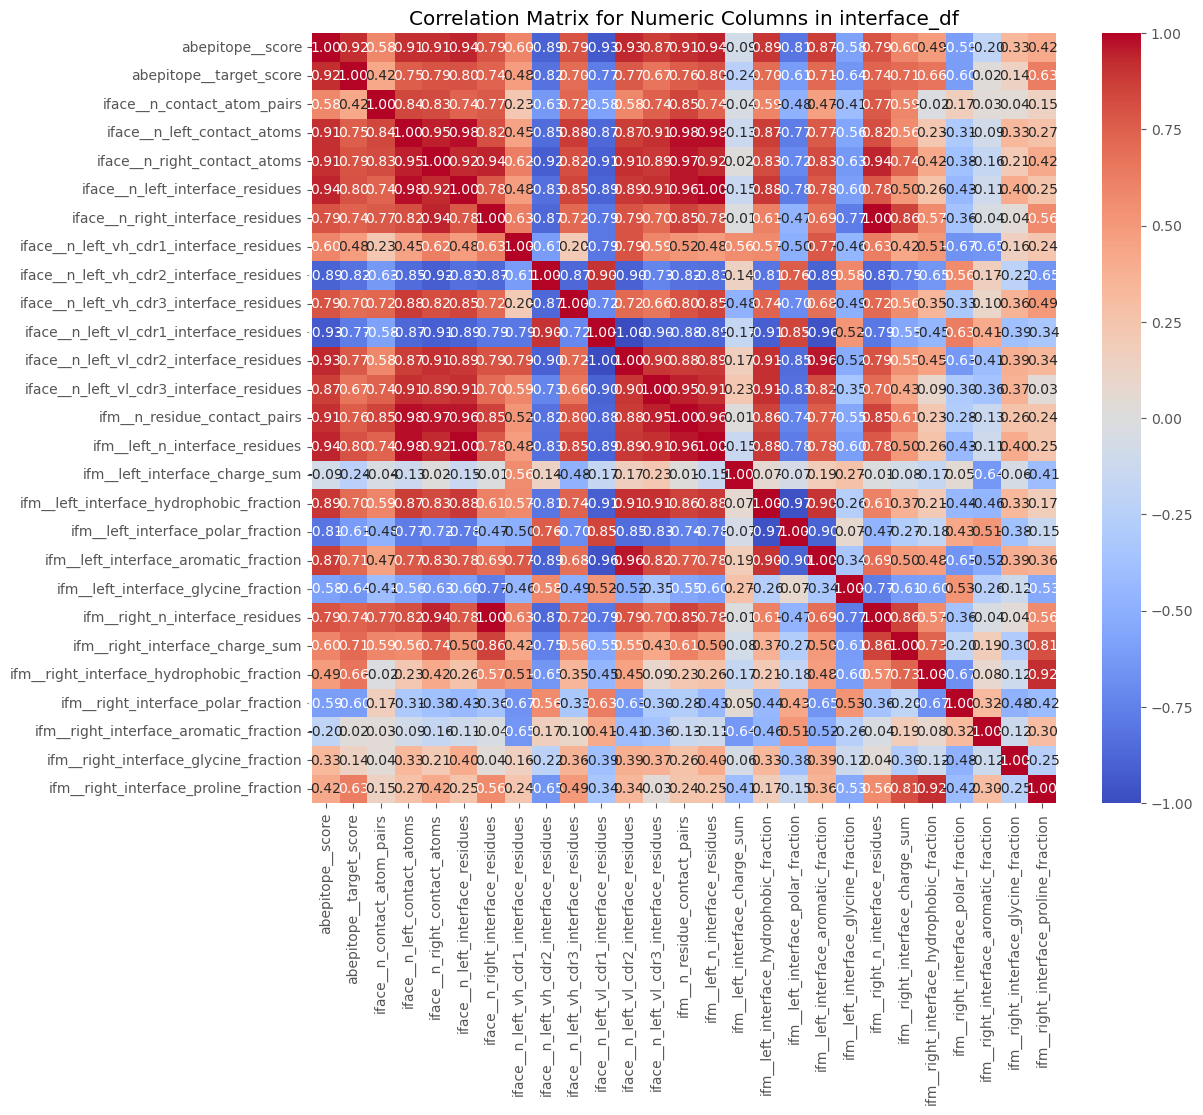

In [56]:
# data analysis for grain == interface
interface_df = grain_dfs['interface']
print(f'interface_df shape: {interface_df.shape}')
display(interface_df.head(20))

# check correlation between columns in interface_df for numeric columns
numeric_cols = interface_df.select_dtypes(include=[np.number]).columns
correlation_matrix = interface_df[numeric_cols].corr()
print('Correlation matrix for numeric columns in interface_df:')
display(correlation_matrix)

# plot correlation matrix as heatmap for column that is not all NaN
import seaborn as sns
correlation_matrix = correlation_matrix.dropna(axis=0, how='all').dropna(axis=1, how='all')
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix for Numeric Columns in interface_df')
plt.show()

